In [1]:
import numpy as np
import os
import re
import torch
from cebra.data import TensorDataset  # adjust import if you use another path
import pandas as pd
from sklearn.model_selection import ParameterGrid,StratifiedKFold, KFold
from joblib import Parallel, delayed, parallel_backend
import json
from sklearn.neighbors import KNeighborsRegressor
import  glob
from sklearn.metrics import r2_score
from scipy.stats import pearsonr, spearmanr
import matplotlib as mpl
mpl.rcParams['svg.fonttype'] = 'none'
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter
import scipy

In [2]:
# Function to standardize subject IDs
def standardize_subj_id(subj_id):
    # Remove leading zeros
    subj_id = subj_id.lstrip("0")
    if subj_id.endswith("T1") or subj_id.endswith("T2"):
        subj_id = subj_id[:-2]
    return subj_id

# ---------- Load dataset 1 (schizophrenia) ----------
path1 = '/workspaces/CEBRA_project/data/Geneva_Schizophrenia_Begue/all_subjects_concat_fMRI_harvardoxford_timeseries.npz'
meta_data_path1 = '/workspaces/CEBRA_project/data/Geneva_Schizophrenia_Begue/final_metadata.xlsx'
session1 = np.load(path1, allow_pickle=True)['session_id']


with np.load(path1, allow_pickle=True) as f:
    subj1 = f['sub_id']      # strings


# Load the .xlsx file using pandas
meta_data_df1 = pd.read_excel(meta_data_path1)

# Ensure that both sub_id columns are strings (or both numerical if needed)
meta_data_df1['sub_id'] = meta_data_df1['sub_id'].astype(str)  # Convert meta_data's sub_id to string



# Standardize subj1 (e.g., remove leading zeros and suffixes 'T1'/'T2' from subject IDs)
subj1_standardized = np.array([standardize_subj_id(subj) for subj in subj1])


# Create a DataFrame with sub_id and session from the .npz data
npz_data_df1 = pd.DataFrame({
    'sub_id': subj1_standardized,  # Use the standardized subject IDs
    'session': session1,
})

# Merge the data based on 'sub_id' and 'session'
merged_df1 = pd.merge(npz_data_df1, meta_data_df1, 
                     left_on=['sub_id', 'session'], right_on=['sub_id', 'session'], how='left')

merged_df1["group"] = merged_df1["group"].map({
    "Schizophrenia": 0,
    "Healthy Control": 1
})

# ---------- Add Movement Data to Dataset 1 (Geneva) ----------
# Update this path to exactly what you named the new CSV file
geneva_motion_path_csv = '/workspaces/CEBRA_project/data/Geneva_Schizophrenia_Begue/MotionSummary_DatasetGENEVA.csv'

# Load the CSV directly into pandas
geneva_motion_df = pd.read_csv(geneva_motion_path_csv)

# --- Process Geneva movement subjects to extract session and match IDs ---
clean_sub_ids = []
sessions = []

for s in geneva_motion_df['Subject']:
    s = str(s)
    
    # 1. Extract session and remove T1/T2 suffix
    if s.endswith("T1"):
        sessions.append(1)
        s = s[:-2]
    elif s.endswith("T2"):
        sessions.append(2)
        s = s[:-2]
    else:
        sessions.append(1)  # Default to session 1 if no suffix
        
    # 2. Remove 'sub-' prefix
    if s.startswith("sub-"):
        s = s[4:]
        
    # 3. Remove leading zeros (e.g., '0101' -> '101', but 'GC001' stays 'GC001')
    s = s.lstrip("0")
    
    clean_sub_ids.append(s)

# Create movement dataframe for Geneva, now including session
df_movement_geneva = pd.DataFrame({
    'sub_id': clean_sub_ids,
    'session': sessions,
    'mean_movement': geneva_motion_df['MFD']
})

# Merge the movement data onto dataset 1 using BOTH sub_id and session
merged_df1 = pd.merge(merged_df1, df_movement_geneva, on=['sub_id', 'session'], how='left')


# ---------- Load dataset 2 (full set with sub_session we will ignore) ----------
path2 = '/workspaces/CEBRA_project/data/HCP-EP/all_subjects_concat_fMRI_harvardoxford_timeseries.npz'
meta_data_path2 = '/workspaces/CEBRA_project/data/HCP-EP/final_metadata.xlsx'
session2 = np.load(path2, allow_pickle=True)['session_id']
with np.load(path2, allow_pickle=True) as f:
    subj2 = f['sub_id']      # currently ints



# Make *both* sides strings
meta_data_df2 = pd.read_excel(meta_data_path2)
meta_data_df2['sub_id'] = meta_data_df2['sub_id'].astype(str)



# Option 1: convert before creating the DataFrame
subj2 = subj2.astype(str)

npz_data_df2 = pd.DataFrame({
    'sub_id': subj2,
    'session': session2,
})

# Option 2: or convert after creating the DataFrame
# npz_data_df2['sub_id'] = npz_data_df2['sub_id'].astype(str)

merged_df2 = pd.merge(
    npz_data_df2,
    meta_data_df2,
    left_on=['sub_id'],
    right_on=['sub_id'],
    how='left'
)

merged_df2["group"] = merged_df2["group"].map({
    "Non-affective psychosis": 0,
    "Affective psychosis": 0,
    "In good health": 1
})

merged_df2['ds_type'] = 2
merged_df1['ds_type'] = 1

# Add movement

# ---------- Add Movement Data to Dataset 2 ----------
# (Make sure the paths to the .mat files are correct for your environment)
list_hcp = scipy.io.loadmat('/workspaces/CEBRA_project/data/HCP-EP/List_HCP.mat')
mfd = scipy.io.loadmat('/workspaces/CEBRA_project/data/HCP-EP/MFD.mat')

# Extract subjects, converting to strings and removing "ses-" 
# so they match the format in merged_df2 (e.g. "1001", "4015")
subjects_mfd = [str(item[0]).replace('ses-', '') for item in list_hcp['List_HCP'][0]]

# Calculate the mean across the 2x2 matrix for each subject
mean_mfd = np.mean(mfd['MFD'], axis=(1, 2))

# Create movement dataframe
df_movement = pd.DataFrame({
    'sub_id': subjects_mfd,
    'mean_movement': mean_mfd
})

# Merge the movement data onto dataset 2 specifically
merged_df2 = pd.merge(merged_df2, df_movement, on='sub_id', how='left')
# ----------------------------------------------------

combined = pd.concat([merged_df1, merged_df2], axis=0, ignore_index=True)
print(combined.columns)

cols_to_nan = [
    "panss_negative",
    "panss_negative_EPA",
    "panss_apathy_Indrit",
    "panss_positive",
]

import numpy as np

combined["CPZ_equivalent_calculated"] = np.where(
    combined["ds_type"] == 2,
    combined["CPZ_score"],
    100 * combined["risperidon_score"]
)


combined.loc[combined["sub_id"] == "4015", cols_to_nan] = np.nan # Did not complete PANSS assessment




Index(['sub_id', 'session', 'risperidon_score', 'bacs_total', 'bacs_att',
       'panss_positive', 'panss_negative', 'panss_negative_EPA',
       'panss_apathy_Indrit', 'age_years', 'sex', 'bnss_apathy', 'group',
       'mean_movement', 'ds_type', 'CAINS_MAP', 'fluid_cognition_score',
       'crystal_cognition_score', 'total_cognition_score',
       'lifetime_antipsychotic_drug', 'CPZ_score', 'money_delay_auc_200',
       'money_delay_auc_40000', 'pattern_processing_speed_NIH',
       'grip_strength_age_unadjusted', 'panss_general', 'interview_age'],
      dtype='object')


In [3]:

mask_pat = (
    (combined['group'] == 0)
)

# Controls (no PANSS requirement)
mask_con = (combined['group'] == 1)

# Dataset type masks (1 = schizophrenia, 2 = HCP-EP)
mask_ds_1 = (combined['ds_type'] == 1)
mask_ds_2 = (combined['ds_type'] == 2)

# Dataset 1 / 2 by group
mask_ds_1_pat = (combined['ds_type'] == 1) & (combined['group'] == 0)
mask_ds_1_con = (combined['ds_type'] == 1) & (combined['group'] == 1)

mask_ds_2_pat = (combined['ds_type'] == 2) & (combined['group'] == 0)
mask_ds_2_con = (combined['ds_type'] == 2) & (combined['group'] == 1)


# Subset using the masks
df_pat        = combined.loc[mask_pat].reset_index(drop=True)
df_con        = combined.loc[mask_con].reset_index(drop=True)

df1        = combined.loc[mask_ds_1].reset_index(drop=True)
df1_pat    = combined.loc[mask_ds_1_pat].reset_index(drop=True)
df1_con    = combined.loc[mask_ds_1_con].reset_index(drop=True)

df2        = combined.loc[mask_ds_2].reset_index(drop=True)
df2_pat    = combined.loc[mask_ds_2_pat].reset_index(drop=True)

# Decoding function

In [4]:
from sklearn.metrics import mean_squared_error
import os

def cv_combined_multi_datasets(
    datasets,
    *,
    target_column=None,
    make_regressor=None,
    decoder_name="model",
    n_splits=5,
    random_state=32,
    stratify_by_subject_y=True,
    max_strata_bins=5,
    use_session_by_dataset=None,   # <-- NEW
):
    """
    ...
    use_session_by_dataset : dict or None
        Mapping dataset label -> bool. Used only for aggregated fold metrics.
        If None, will infer from datasets list (ds['use_session']).
    """
    import numpy as np, pandas as pd
    from sklearn.model_selection import KFold, StratifiedKFold
    from sklearn.metrics import mean_absolute_error, r2_score
    from scipy.stats import pearsonr

    assert target_column is not None, "Please set target_column (column in df)."
    assert callable(make_regressor), "make_regressor must be a callable."

    # ----------------- helpers -----------------
    def ensure_numpy(x):
        try:
            import torch
            if hasattr(x, "detach"):
                return x.detach().cpu().numpy()
        except Exception:
            pass
        return x if isinstance(x, np.ndarray) else np.asarray(x)

    def _rmse(y_true, y_pred):
        try:
            return mean_squared_error(y_true, y_pred, squared=False)
        except TypeError:
            return np.sqrt(mean_squared_error(y_true, y_pred))

    def _r_pearson(a, b):
        if len(a) < 2:
            return np.nan
        if np.std(a) == 0 or np.std(b) == 0:
            return np.nan
        r, _ = pearsonr(a, b)
        return float(r)



    # ----------------- infer use_session_by_dataset if not provided -----------------
    if use_session_by_dataset is None:
        use_session_by_dataset = {}
        for ds in datasets:
            use_session_by_dataset[ds["label"]] = bool(ds.get("use_session", True))

    # ----------------- collect / combine all datasets -----------------
    X_all, subj_all, sess_all, y_all, lab_all = [], [], [], [], []

    for ds in datasets:
        X_i = ensure_numpy(ds["embedding"])
        df_i = ds["df"]
        label_i = ds["label"]
        use_session = ds.get("use_session", True)

        s_i = df_i["sub_id"].astype(str).to_numpy()

        if use_session and ("session" in df_i.columns):
            ses_i = _to_int_session(df_i["session"].to_numpy())
        else:
            ses_i = np.zeros(len(s_i), dtype=int)

        y_i = pd.to_numeric(df_i[target_column], errors="coerce").to_numpy(dtype=float)
        lab_i_arr = np.full(len(s_i), label_i, dtype=object)

        m = np.isfinite(y_i)
        if not np.any(m):
            continue
        X_i, s_i, ses_i, y_i, lab_i_arr = X_i[m], s_i[m], ses_i[m], y_i[m], lab_i_arr[m]

        X_all.append(X_i)
        subj_all.append(s_i)
        sess_all.append(ses_i)
        y_all.append(y_i)
        lab_all.append(lab_i_arr)
    
    if len(X_all) == 0:
        raise RuntimeError(
            f"No valid samples found for target_column='{target_column}' across all datasets."
        )

    Xc     = np.concatenate(X_all, axis=0)
    subj_c = np.concatenate(subj_all, axis=0)
    sess_c = np.concatenate(sess_all, axis=0)
    y_c    = np.concatenate(y_all, axis=0)
    lab_c  = np.concatenate(lab_all, axis=0)

    subj_c_pref = np.array([f"{lab}:{sid}" for lab, sid in zip(lab_c, subj_c)], dtype=object)

    # ----------------- subject-held-out CV with fixed per-dataset quotas -----------------
    subj_tbl = (
        pd.DataFrame({"dataset": lab_c, "subj_pref": subj_c_pref, "y": y_c})
        .groupby(["dataset", "subj_pref"], sort=True)["y"]
        .mean()
        .reset_index()
        .rename(columns={"y": "y_mean"})
    )

    def _make_strata_from_values(values, n_splits, max_bins=10):
        values = np.asarray(values, dtype=float)
        for bins in range(max_bins, 1, -1):
            try:
                labels = pd.qcut(values, q=bins, labels=False, duplicates="drop")
            except Exception:
                continue
            counts = pd.Series(labels).value_counts()
            if (counts >= n_splits).all() and counts.min() > 0 and len(np.unique(labels)) >= 2:
                return labels.astype(int)
        return None

    per_ds_splits = {}
    for ds_lab, g in subj_tbl.groupby("dataset", sort=True):
        subs = g["subj_pref"].to_numpy()
        ymean = g["y_mean"].to_numpy()

        strata = _make_strata_from_values(ymean, n_splits, max_bins=max_strata_bins) if stratify_by_subject_y else None

        if strata is not None:
            splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
            split_iter = splitter.split(subs, strata)
        else:
            splitter = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
            split_iter = splitter.split(subs)

        splits = []
        for tr_idx, va_idx in split_iter:
            splits.append((set(subs[tr_idx]), set(subs[va_idx])))
        per_ds_splits[ds_lab] = splits

    # ----------------- run folds -----------------
    oof_records = []
    for fold in range(1, n_splits + 1):
        va_sub, tr_sub = set(), set()
        for ds_lab, splits in per_ds_splits.items():
            tr_s, va_s = splits[fold - 1]
            tr_sub |= tr_s
            va_sub |= va_s

        tr_mask = np.array([s in tr_sub for s in subj_c_pref])
        va_mask = np.array([s in va_sub for s in subj_c_pref])

        X_tr = Xc[tr_mask]
        X_va = Xc[va_mask]
        y_tr, y_va = y_c[tr_mask], y_c[va_mask]
        sess_va = sess_c[va_mask]
        subj_va = subj_c[va_mask]
        lab_va  = lab_c[va_mask]

        reg = make_regressor()
        reg.fit(X_tr, y_tr)
        y_pred_va = reg.predict(X_va)

        df_va = pd.DataFrame(
            {
                "dataset": lab_va,
                "sub_id": subj_va,
                "session": sess_va,
                "y_true": y_va,
                "y_pred": y_pred_va,
                "fold": fold,
            }
        )
        oof_records.append(df_va)

        # ---- frame-level metrics ----
        rmse_f = _rmse(y_va, y_pred_va)
        r2_f   = r2_score(y_va, y_pred_va) if len(np.unique(y_va)) > 1 else np.nan
        r_f    = _r_pearson(y_va, y_pred_va)

        # ---- aggregated metrics ----
        df_va_agg = aggregate_for_eval(df_va, use_session_by_dataset)
        rmse_a = _rmse(df_va_agg["y_true"].to_numpy(), df_va_agg["y_pred"].to_numpy())
        r2_a   = r2_score(df_va_agg["y_true"], df_va_agg["y_pred"]) if df_va_agg["y_true"].nunique() > 1 else np.nan
        r_a    = _r_pearson(df_va_agg["y_true"].to_numpy(), df_va_agg["y_pred"].to_numpy())
        n_groups = len(df_va_agg)

        print(
            f"[{decoder_name} | fold {fold}/{n_splits}] "
            f"frames={len(y_va)} RMSE={rmse_f:.3f} R2={r2_f:.3f} r={r_f:.3f} | "
            f"agg_groups={n_groups} RMSE_agg={rmse_a:.3f} R2_agg={r2_a:.3f} r_agg={r_a:.3f}"
        )

    df_oof = pd.concat(oof_records, axis=0, ignore_index=True)
    return {"oof_frames": df_oof}


# Sweep best decoder

In [5]:


def _to_jsonable(x):
    # numpy scalars -> python scalars
    if isinstance(x, (np.integer,)):
        return int(x)
    if isinstance(x, (np.floating,)):
        return float(x)
    if isinstance(x, (np.bool_,)):
        return bool(x)
    # tuples/sets -> lists for JSON
    if isinstance(x, tuple):
        return [_to_jsonable(v) for v in x]
    if isinstance(x, list):
        return [_to_jsonable(v) for v in x]
    if isinstance(x, set):
        return sorted(_to_jsonable(v) for v in x)
    # None/bool/int/float/str are already fine
    return x

def params_signature(params: dict) -> str:
    canon = {k: _to_jsonable(v) for k, v in params.items()}
    # canonical string: stable order + no whitespace
    return json.dumps(canon, sort_keys=True, separators=(",", ":"))


def params_to_key(decoder_name, params: dict):
    return (decoder_name, params_signature(params))



def cv_sweep_decoders(
    datasets,
    *,
    target_column,
    decoder_specs,
    n_splits=5,
    random_state=32,
    stratify_by_subject_y=True,
    max_strata_bins=5,
    n_jobs_outer=-1,
    existing_param_keys=None,   
):

    def run_one(dec_name, builder, params):
        def make_regressor(builder=builder, params=params, rs=random_state):
            kw = dict(params)
            try:
                return builder(random_state=rs, **kw)
            except TypeError:
                return builder(**kw)

        out = cv_combined_multi_datasets(
            datasets=datasets,
            target_column=target_column,
            make_regressor=make_regressor,
            decoder_name=f"{dec_name} {params}",
            n_splits=n_splits,
            random_state=random_state,
            stratify_by_subject_y=stratify_by_subject_y,
            max_strata_bins=max_strata_bins,
        )

        df = out["oof_frames"].copy()
        df["decoder"] = dec_name
        for k, v in params.items():
            df[f"hp_{k}"] = [v] * len(df)
        df["params_json"] = params_signature(params)
        return df

    jobs = []
    skipped = 0

    for dec_name, spec in decoder_specs.items():
        builder    = spec["builder"]
        param_grid = spec.get("param_grid", {})

        for params in ParameterGrid(param_grid):
            key = params_to_key(dec_name, params)

            if existing_param_keys is not None and key in existing_param_keys:
                skipped += 1
                continue

            jobs.append((dec_name, builder, params))


    # IMPORTANT: if everything is already there, return an empty DataFrame
    if not jobs:
        print("[INFO] All hyperparameter combinations already present; nothing to run.")
        return pd.DataFrame()

    results = Parallel(n_jobs=n_jobs_outer)(
        delayed(run_one)(dec_name, builder, params)
        for dec_name, builder, params in jobs
    )

    return pd.concat(results, axis=0, ignore_index=True)




# Decoder config

In [6]:


random_state = 0

decoder_specs = {

    "knn": {
        "builder": lambda **kw: KNeighborsRegressor(
            algorithm="brute",
            n_jobs=1,
            **kw
        ),
        "param_grid": {
            "n_neighbors": [1,10,25, 50,100,500,1000,5000],
            "metric": ["euclidean"],
            "weights": ["uniform", "distance"],
        },
    }
}

# Outer split

In [7]:


def outer_subject_folds(
    datasets,
    *,
    target_column,
    n_splits_outer=10,          # <-- 10 folds => ~0.1 test each fold
    random_state=0,
    stratify_by_subject_y=True,
    max_strata_bins=5,
):
    """
    Returns: list of (train_subjects_pref, test_subjects_pref) for each outer fold.
    Each element is a set of 'label:sub_id'.

    Guarantee: within each dataset, each subject appears in test exactly once
               across the n_splits_outer folds (KFold/StratifiedKFold property).
    """
    folds_train = [set() for _ in range(n_splits_outer)]
    folds_test  = [set() for _ in range(n_splits_outer)]

    def _make_strata(values, n_splits, max_bins):
        values = np.asarray(values, dtype=float)
        for bins in range(max_bins, 1, -1):
            try:
                lab = pd.qcut(values, q=bins, labels=False, duplicates="drop")
            except Exception:
                continue
            c = pd.Series(lab).value_counts()
            # need every stratum to have at least n_splits members
            if (c >= n_splits).all() and len(np.unique(lab)) >= 2:
                return lab.astype(int)
        return None

    for ds in datasets:
        df  = ds["df"]
        lab = ds["label"]

        s = df["sub_id"].astype(str).to_numpy()
        y = pd.to_numeric(df[target_column], errors="coerce").to_numpy(dtype=float)
        m = np.isfinite(y)
        s, y = s[m], y[m]

        subj_tbl = (
            pd.DataFrame({"sub": s, "y": y})
            .groupby("sub", sort=True)["y"].mean()
            .reset_index()
        )

        if subj_tbl.empty:
            print(f"[OUTER] Skipping dataset {lab}: no finite y for target '{target_column}'")
            continue

        # --- NEW: if not enough subjects to support n_splits_outer, skip dataset ---
        if len(subj_tbl) < n_splits_outer:
            print(
                f"[OUTER] Skipping dataset {lab}: only {len(subj_tbl)} subjects with finite y "
                f"(< n_splits_outer={n_splits_outer}) for target '{target_column}'"
            )
            continue

        subs  = subj_tbl["sub"].astype(str).to_numpy()
        ymean = subj_tbl["y"].to_numpy()
        subs_pref = np.array([f"{lab}:{sid}" for sid in subs], dtype=object)

        if stratify_by_subject_y:
            strata = _make_strata(ymean, n_splits_outer, max_strata_bins)
        else:
            strata = None

        if strata is not None:
            splitter = StratifiedKFold(
                n_splits=n_splits_outer, shuffle=True, random_state=random_state
            )
            split_iter = splitter.split(subs_pref, strata)
            print(f"[OUTER] StratifiedKFold for dataset {lab} (n_splits={n_splits_outer})")
        else:
            splitter = KFold(
                n_splits=n_splits_outer, shuffle=True, random_state=random_state
            )
            split_iter = splitter.split(subs_pref)
            print(f"[OUTER] KFold (no strat) for dataset {lab} (n_splits={n_splits_outer})")

        for fold_idx, (tr_idx, te_idx) in enumerate(split_iter):
            folds_train[fold_idx] |= set(subs_pref[tr_idx])
            folds_test[fold_idx]  |= set(subs_pref[te_idx])

    return list(zip(folds_train, folds_test))


def filter_datasets_by_subjects(datasets, subject_pref_set):
    """
    Return a new datasets list where each ds is filtered to frames whose
    'label:sub_id' is in subject_pref_set.
    """
    out = []
    for ds in datasets:
        df = ds["df"].copy()
        lab = ds["label"]
        s = df["sub_id"].astype(str).to_numpy()
        pref = np.array([f"{lab}:{sid}" for sid in s], dtype=object)
        keep = np.array([p in subject_pref_set for p in pref])

        out.append(
            dict(
                embedding=np.asarray(ds["embedding"])[keep],
                df=df.iloc[keep].reset_index(drop=True),
                label=lab,
                use_session=ds.get("use_session", True),
            )
        )
    return out

def _build_ds_list_from_parts(parts, datasets_config):
    ds_list = []
    for cfg in datasets_config:
        embed_key = cfg["embed_key"]
        if embed_key not in parts:
            raise KeyError(
                f"slicer output has no key '{embed_key}'. "
                f"Available keys: {list(parts.keys())}"
            )
        ds_list.append(
            dict(
                embedding=parts[embed_key],
                df=cfg["df"],
                label=cfg["label"],
                use_session=cfg.get("use_session", True),
            )
        )
    return ds_list


# Run loop

In [8]:
# ---- strong reproducibility / avoid oversubscription ----

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["BLIS_NUM_THREADS"] = "1"




# -----------------------------
# Config
# -----------------------------
RS = 0
N_OUTER = 10
N_INNER = 5

# IMPORTANT: Option A -> no nested process-parallel.
# Inner CV uses n_jobs_outer=1 to avoid oversubscription.
INNER_N_JOBS = 4 

# Outer parallelism: set as high as you want given memory.
OUTER_N_JOBS = 5


target_columns = ['panss_negative_EPA','panss_positive','CPZ_equivalent_calculated',
        'bacs_att','total_cognition_score',   'age_years', 'bnss_apathy'
]

out_dir = "/workspaces/CEBRA_project/Scripts_to_publish/decoder_results_only_kNN_xCEBRA"
os.makedirs(out_dir, exist_ok=True)

master_best_path = os.path.join(out_dir, "best_all_targets.csv")
master_test_path = os.path.join(out_dir, "test_all_targets.csv")
master_val_path  = os.path.join(out_dir, "val_scores_all_targets.csv")

completed_json = os.path.join(out_dir, "completed_targets.json")

ref_npz_dir  = "/workspaces/CEBRA_project/Scripts_to_publish/xCEBRA_models_to_publish/ensembled_embeddings/regularizer_weight_10p0"
ref_npz_glob = "ensemble_avg_weight10p0.npz"
ref_npz_paths = sorted(glob.glob(os.path.join(ref_npz_dir, ref_npz_glob)))
if not ref_npz_paths:
    raise FileNotFoundError(f"No npz found in {ref_npz_dir} with pattern {ref_npz_glob}")


# -----------------------------
# Utilities
# -----------------------------
def safe_name(name: str) -> str:
    return re.sub(r"[^0-9a-zA-Z_]+", "_", str(name))

def extract_ref_tag(npz_path: str) -> str:
    m = re.search(r"_ref-([^_]+)_subsampled\.npz$", os.path.basename(npz_path))
    return m.group(1) if m else os.path.splitext(os.path.basename(npz_path))[0]

def ensure_dir(p):
    os.makedirs(p, exist_ok=True)
    return p

def read_header_cols(path):
    return pd.read_csv(path, nrows=0).columns.tolist()

def assert_has_columns_or_empty(path, required_cols, kind="file"):
    if not os.path.exists(path):
        return
    cols = read_header_cols(path)
    missing = [c for c in required_cols if c not in cols]
    if missing:
        raise RuntimeError(
            f"{kind} {path} is legacy / incompatible (missing columns: {missing}). "
            f"Rename or delete it before running."
        )

def merge_fold_csvs(pattern, out_path, sort_cols=None, drop_dupe_cols=None):
    """
    Merge all CSVs matching pattern into out_path (overwrite).
    Optionally sort and drop duplicates.
    """
    paths = sorted(glob.glob(pattern))
    if not paths:
        return None

    dfs = [pd.read_csv(p) for p in paths]
    df = pd.concat(dfs, axis=0, ignore_index=True)

    if drop_dupe_cols is not None:
        df = df.drop_duplicates(subset=drop_dupe_cols, keep="last")

    if sort_cols is not None:
        df = df.sort_values(sort_cols).reset_index(drop=True)

    df.to_csv(out_path, index=False)
    return out_path

def _to_int_session(arr):
    s = pd.Series(arr)
    try:
        return s.astype(int).to_numpy()
    except Exception:
        v = s.astype(str).str.extract(r"(-?\d+)")[0]
        return pd.to_numeric(v, errors="coerce").to_numpy()

def slicer_from_masks(combined_avg):
    # assumes mask_ds_1_pat, mask_ds_2_pat exist in your environment
    return {
        "ds1_embed": combined_avg[mask_ds_1_pat],
        "ds2_embed": combined_avg[mask_ds_2_pat],
    }


from scipy.stats import pearsonr, spearmanr

def _metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true, y_pred = y_true[m], y_pred[m]
    n = int(y_true.size)

    if n < 2:
        return dict(
            n=n,
            pearson=np.nan,
            pearson_p=np.nan,
            spearman=np.nan,
            r2=np.nan,
        )

    # Pearson
    if np.std(y_true) == 0 or np.std(y_pred) == 0:
        pear = np.nan
        pear_p = np.nan
    else:
        pear, pear_p = pearsonr(y_true, y_pred)
        pear = float(pear)
        pear_p = float(pear_p)

    # Spearman
    sp = spearmanr(y_true, y_pred).correlation
    sp = float(sp) if np.isfinite(sp) else np.nan

    # R2
    r2 = float(r2_score(y_true, y_pred)) if np.unique(y_true).size > 1 else np.nan

    return dict(
        n=n,
        pearson=pear,
        pearson_p=pear_p,   # ← NEW
        spearman=sp,
        r2=r2,
    )



# ------------------------------------------------------------
# Aggregation helper: must match your eval rule
# ------------------------------------------------------------
def aggregate_for_eval(df, use_session_by_dataset):
    """
    df must have: dataset, sub_id, session, y_true, y_pred
    For datasets with use_session=False -> session_grp=0
    """
    df = df.copy()
    df["sub_id"] = df["sub_id"].astype(str)

    use_s = df["dataset"].map(lambda d: bool(use_session_by_dataset.get(d, True))).to_numpy()
    sess = pd.to_numeric(df.get("session", 0), errors="coerce").fillna(0).astype(int).to_numpy()
    df["session_grp"] = np.where(use_s, sess, 0)

    agg = (
        df.groupby(["dataset", "sub_id", "session_grp"], sort=False)
          .agg(y_true=("y_true", "mean"), y_pred=("y_pred", "mean"))
          .reset_index()
    )
    return agg


# ------------------------------------------------------------
# Build full list of (decoder, params_json) combos from decoder_specs
# ------------------------------------------------------------
def all_decoder_param_combos(decoder_specs):
    combos = []
    for dec_name, spec in decoder_specs.items():
        grid = spec.get("param_grid", {})
        for params in ParameterGrid(grid):
            combos.append((dec_name, params_signature(params), params))
    return combos


# -----------------------------
# Per-fold worker
# -----------------------------
def run_one_outer_fold(
    *,
    npz_path,
    ref_tag,
    tcol,
    outer_i,
    ds_all,                 # list of datasets dicts (already built in parent)
    tr_sub,
    te_sub,
    use_session_by_dataset,
    fold_dir,
):
    """
    Runs one outer fold:
      - inner CV sweep: OOF preds for ALL decoder/hp (frames)
      - aggregate OOF to subject(/session) level for ALL decoder/hp and save
      - compute val metrics for ALL decoder/hp and select best
      - fit EVERY decoder/hp on full train, predict test, aggregate, save
      - mark best-val decoder/hp on test outputs
    """

    ensure_dir(fold_dir)

    # ---- fold-specific output files (unique -> safe in parallel) ----
    # CV OOF aggregated (subject/session level, all decoders)
    cv_oof_agg_path = os.path.join(
        fold_dir, f"cv_oof_agg_all_{safe_name(tcol)}_{safe_name(ref_tag)}_outer{outer_i:02d}.csv"
    )
    # VAL scores per decoder/hp
    val_scores_path = os.path.join(
        fold_dir, f"val_scores_{safe_name(tcol)}_{safe_name(ref_tag)}_outer{outer_i:02d}.csv"
    )

    # TEST preds aggregated (subject/session level, all decoders + is_best_val)
    test_agg_path = os.path.join(
        fold_dir, f"test_preds_agg_all_{safe_name(tcol)}_{safe_name(ref_tag)}_outer{outer_i:02d}.csv"
    )
    # BEST summary (one row)
    best_path = os.path.join(
        fold_dir, f"best_{safe_name(tcol)}_{safe_name(ref_tag)}_outer{outer_i:02d}.csv"
    )

    # ---- build ds_tr / ds_te ----
    ds_tr = filter_datasets_by_subjects(ds_all, tr_sub)
    ds_te = filter_datasets_by_subjects(ds_all, te_sub)

    # ---- Run inner CV sweep for ALL decoder/hp combos ----
    # Use resume keys from val_scores if present (optional)
    existing_param_keys = None
    if os.path.exists(val_scores_path):
        df_prev = pd.read_csv(val_scores_path)
        if not df_prev.empty:
            existing_param_keys = set(zip(df_prev["decoder"].astype(str), df_prev["params_json"].astype(str)))

    df_oof_new = cv_sweep_decoders(
        datasets=ds_tr,
        target_column=tcol,
        decoder_specs=decoder_specs,
        n_splits=N_INNER,
        random_state=RS,
        stratify_by_subject_y=True,
        max_strata_bins=5,
        n_jobs_outer=INNER_N_JOBS,          # Option A: keep 1 here (no nesting)
        existing_param_keys=existing_param_keys,
    )

    # ---- Build aggregated OOF per decoder/hp ----
    # We aggregate separately for each (decoder, params_json)
    oof_agg_rows = []
    val_rows = []

    if df_oof_new.empty:
        raise RuntimeError(
            f"No new OOF produced for {tcol}/{ref_tag}/outer{outer_i:02d}. "
            f"Since you disabled frame-level caching, resume is not possible."
        )

    # (optional but useful) add metadata before aggregation
    df_oof_new2 = df_oof_new.copy()
    df_oof_new2["ref_tag"] = ref_tag
    df_oof_new2["target_column"] = tcol
    df_oof_new2["outer_fold"] = outer_i

    oof_agg_rows = []
    val_rows = []

    for (dec, sig), g in df_oof_new2.groupby(["decoder", "params_json"], sort=False):
        agg = aggregate_for_eval(g, use_session_by_dataset)
        agg["decoder"] = dec
        agg["params_json"] = sig
        agg["ref_tag"] = ref_tag
        agg["target_column"] = tcol
        agg["outer_fold"] = outer_i
        agg["split"] = "cv_oof_agg"
        oof_agg_rows.append(agg)

        met = _metrics(agg["y_true"].to_numpy(), agg["y_pred"].to_numpy())
        val_rows.append(dict(
            ref_tag=ref_tag,
            target_column=tcol,
            outer_fold=outer_i,
            decoder=dec,
            params_json=sig,
            val_pearson_agg=met["pearson"],
            val_spearman_agg=met["spearman"],
            val_r2_agg=met["r2"],
            val_n_groups=met["n"],
        ))


    df_oof_agg_all = pd.concat(oof_agg_rows, axis=0, ignore_index=True) if oof_agg_rows else pd.DataFrame()
    df_val_all = pd.DataFrame(val_rows)

    # Save aggregated OOF and val scores
    df_oof_agg_all.to_csv(cv_oof_agg_path, index=False)
    df_val_all.to_csv(val_scores_path, index=False)

    if df_val_all.empty or df_val_all["val_pearson_agg"].dropna().empty:
        raise RuntimeError(f"No usable validation scores for {tcol}/{ref_tag}/outer{outer_i:02d}")

    # ---- Choose BEST decoder/hp for this fold (tie-broken deterministically) ----
    df_val_all = df_val_all.sort_values(
        ["val_pearson_agg", "decoder", "params_json"],
        ascending=[False, True, True],
        kind="mergesort"
    ).reset_index(drop=True)

    best = df_val_all.iloc[0]
    best_decoder = str(best["decoder"])
    best_sig = str(best["params_json"])
    best_val_pearson = float(best["val_pearson_agg"])
    best_val_spearman = float(best["val_spearman_agg"]) if np.isfinite(best["val_spearman_agg"]) else np.nan
    best_val_r2 = float(best["val_r2_agg"]) if np.isfinite(best["val_r2_agg"]) else np.nan
    best_val_n = int(best["val_n_groups"])

    # ---- Prepare test meta (frame-level) once ----
    meta_frames = []
    X_te_list = []
    for d in ds_te:
        df = d["df"].copy()
        X = np.asarray(d["embedding"])
        y = pd.to_numeric(df[tcol], errors="coerce").to_numpy(dtype=float)

        mte = np.isfinite(y)
        df = df.iloc[mte].reset_index(drop=True)
        X = X[mte]
        y = y[mte]

        use_s = d.get("use_session", True)
        ses = _to_int_session(df["session"].to_numpy()) if (use_s and "session" in df.columns) else np.zeros(len(df), dtype=int)

        meta_frames.append(pd.DataFrame({
            "dataset": np.full(len(df), d["label"], dtype=object),
            "sub_id": df["sub_id"].astype(str).to_numpy(),
            "session": ses,
            "y_true": y,
        }))
        X_te_list.append(X)

    df_test_meta = pd.concat(meta_frames, ignore_index=True) if meta_frames else pd.DataFrame(
        columns=["dataset","sub_id","session","y_true"]
    )
    X_te = np.concatenate(X_te_list, axis=0) if X_te_list else np.zeros((0, np.asarray(ds_tr[0]["embedding"]).shape[1]))

    # ---- Train arrays for full train split ----
    X_tr = np.concatenate([np.asarray(d["embedding"]) for d in ds_tr], axis=0)
    y_tr = np.concatenate([pd.to_numeric(d["df"][tcol], errors="coerce").to_numpy(dtype=float) for d in ds_tr], axis=0)
    mtr = np.isfinite(y_tr)
    X_tr, y_tr = X_tr[mtr], y_tr[mtr]

    # ---- Predict TEST with EVERY decoder/hp ----
    # We reconstruct params from params_json using the spec grids
    combos = all_decoder_param_combos(decoder_specs)
    # quick map: (decoder, params_json) -> params dict
    combo_map = {(d, sig): params for (d, sig, params) in combos}

    test_agg_all = []

    for (dec, sig), params in combo_map.items():
        # build model
        builder = decoder_specs[dec]["builder"]
        try:
            reg = builder(random_state=RS, **params)
        except TypeError:
            reg = builder(**params)

        # fit/predict
        reg.fit(X_tr, y_tr)
        y_pred = reg.predict(X_te) if len(df_test_meta) else np.array([], dtype=float)

        # frame-level test preds (what you asked for: true/pred + subject/session info)
        df_tf = df_test_meta.copy()
        df_tf["y_pred"] = y_pred
        df_tf["decoder"] = dec
        df_tf["params_json"] = sig
        df_tf["ref_tag"] = ref_tag
        df_tf["target_column"] = tcol
        df_tf["outer_fold"] = outer_i
        df_tf["split"] = "test_frames"
        df_tf["is_best_val"] = (dec == best_decoder and sig == best_sig)

        # aggregated test preds
        agg = aggregate_for_eval(df_tf, use_session_by_dataset)
        agg["decoder"] = dec
        agg["params_json"] = sig
        agg["ref_tag"] = ref_tag
        agg["target_column"] = tcol
        agg["outer_fold"] = outer_i
        agg["split"] = "test_agg"
        agg["is_best_val"] = (dec == best_decoder and sig == best_sig)
        test_agg_all.append(agg)

    df_test_agg_all = pd.concat(test_agg_all, axis=0, ignore_index=True) if test_agg_all else pd.DataFrame()

    df_test_agg_all.to_csv(test_agg_path, index=False)

    # ---- Compute TEST metrics for the BEST val decoder/hp (aggregated) ----
    df_best_test = df_test_agg_all[(df_test_agg_all["is_best_val"] == True)].copy()
    met_test_best = _metrics(df_best_test["y_true"].to_numpy(), df_best_test["y_pred"].to_numpy())
    test_best_pearson = met_test_best["pearson"]
    test_best_spearman = met_test_best["spearman"]
    test_best_r2 = met_test_best["r2"]
    test_best_n = met_test_best["n"]

    # ---- Save one-row best summary ----
    df_best = pd.DataFrame([{
        "ref_tag": ref_tag,
        "target_column": tcol,
        "outer_fold": outer_i,
        "best_decoder": best_decoder,
        "best_params_json": best_sig,

        "best_val_pearson_agg": best_val_pearson,
        "best_val_spearman_agg": best_val_spearman,
        "best_val_r2_agg": best_val_r2,
        "best_val_n_groups": best_val_n,

        "best_test_pearson_agg": float(test_best_pearson) if np.isfinite(test_best_pearson) else np.nan,
        "best_test_spearman_agg": float(test_best_spearman) if np.isfinite(test_best_spearman) else np.nan,
        "best_test_r2_agg": float(test_best_r2) if np.isfinite(test_best_r2) else np.nan,
        "best_test_n_groups": int(test_best_n),

        "random_state": RS,
        "inner_n_splits": N_INNER,
        "test_size": 1.0 / N_OUTER,
    }])
    df_best.to_csv(best_path, index=False)

    return {
        "ref_tag": ref_tag,
        "target_column": tcol,
        "outer_fold": outer_i,
        "best_decoder": best_decoder,
        "best_val_pearson": float(best_val_pearson),
        "best_test_pearson": float(test_best_pearson) if np.isfinite(test_best_pearson) else np.nan,
        "fold_dir": fold_dir,
    }


# -----------------------------
# Main
# -----------------------------
if os.path.exists(completed_json):
    with open(completed_json, "r") as f:
        completed_targets = set(json.load(f))
else:
    completed_targets = set()

fold_root = ensure_dir(os.path.join(out_dir, "fold_outputs"))

for tcol in target_columns:
    if tcol in completed_targets:
        print(f"[SKIP TARGET] {tcol} already completed")
        continue

    print(f"\n=== Target: {tcol} ===")

    # canonical merged outputs (per target)
    best_path_t = os.path.join(out_dir, f"best_{safe_name(tcol)}.csv")
    val_path_t  = os.path.join(out_dir, f"val_scores_{safe_name(tcol)}.csv")

    cv_oof_agg_all_path_t  = os.path.join(out_dir, f"cv_oof_agg_all_{safe_name(tcol)}.csv")
    test_agg_all_path_t    = os.path.join(out_dir, f"test_preds_agg_all_{safe_name(tcol)}.csv")

    assertion_configs = [
        # --- Target-Specific Files ---
        (best_path_t, 
         ["ref_tag","target_column","outer_fold","best_decoder","best_params_json",
          "best_val_pearson_agg","best_val_spearman_agg","best_val_r2_agg","best_val_n_groups",
          "best_test_pearson_agg","best_test_spearman_agg","best_test_r2_agg","best_test_n_groups",
          "random_state","inner_n_splits","test_size"], 
         "best"),

        (val_path_t, 
         ["ref_tag","target_column","outer_fold","decoder","params_json",
          "val_pearson_agg","val_spearman_agg","val_r2_agg","val_n_groups"], 
         "val_scores"),

        (cv_oof_agg_all_path_t, 
         ["dataset","sub_id","session_grp","y_true","y_pred",
          "decoder","params_json","ref_tag","target_column","outer_fold","split"], 
         "cv_oof_agg_all"),

        (test_agg_all_path_t, 
         ["dataset","sub_id","session_grp","y_true","y_pred",
          "decoder","params_json","ref_tag","target_column","outer_fold","split","is_best_val"], 
         "test_agg_all"),

        # --- Master Files ---
        (master_best_path, 
         ["ref_tag","target_column","outer_fold","best_decoder","best_params_json",
          "best_val_pearson_agg","best_val_spearman_agg","best_val_r2_agg","best_val_n_groups",
          "best_test_pearson_agg","best_test_spearman_agg","best_test_r2_agg","best_test_n_groups",
          "random_state","inner_n_splits","test_size"], 
         "master_best"),

        (master_val_path, 
         ["ref_tag","target_column","outer_fold","decoder","params_json",
          "val_pearson_agg","val_spearman_agg","val_r2_agg","val_n_groups"], 
         "master_val"),

        (master_test_path, 
         ["dataset","sub_id","session_grp","y_true","y_pred",
          "decoder","params_json","ref_tag","target_column","outer_fold","split","is_best_val"], 
         "master_test"),
    ]

    # 2. Run the loop
    for path, cols, kind in assertion_configs:
        assert_has_columns_or_empty(path, cols, kind=kind)

    # -----------------------------
    # Build ALL jobs across all ref_tags × outer folds
    # -----------------------------
    jobs = []
    fold_dir_t = ensure_dir(os.path.join(fold_root, safe_name(tcol)))

    for npz_path in ref_npz_paths:
        ref_tag = extract_ref_tag(npz_path)

        z = np.load(npz_path, mmap_mode="r", allow_pickle=False)
        combined_avg = np.array(z["combined_avg"], copy=True)
        z.close()
        assert combined_avg.shape[0] == len(combined), (combined_avg.shape, len(combined))

        datasets_config_local = [
            {"embed_key": "ds1_embed", "df": df1_pat, "label": "ds1", "use_session": True},
            {"embed_key": "ds2_embed", "df": df2_pat, "label": "ds2", "use_session": False},
        ]
        use_session_by_dataset = {cfg["label"]: bool(cfg.get("use_session", True)) for cfg in datasets_config_local}

        parts = slicer_from_masks(combined_avg)
        ds_all = _build_ds_list_from_parts(parts, datasets_config_local)

        outer_folds = outer_subject_folds(
            ds_all,
            target_column=tcol,
            n_splits_outer=N_OUTER,
            random_state=RS,
            stratify_by_subject_y=True,
            max_strata_bins=5,
        )

        for outer_i, (tr_sub, te_sub) in enumerate(outer_folds, start=1):
            fold_dir = ensure_dir(os.path.join(fold_dir_t, safe_name(ref_tag)))

            # skip if best file exists (fold fully done)
            best_fold_path = os.path.join(fold_dir, f"best_{safe_name(tcol)}_{safe_name(ref_tag)}_outer{outer_i:02d}.csv")
            if os.path.exists(best_fold_path):
                continue

            jobs.append(dict(
                npz_path=npz_path,
                ref_tag=ref_tag,
                tcol=tcol,
                outer_i=outer_i,
                ds_all=ds_all,
                tr_sub=tr_sub,
                te_sub=te_sub,
                use_session_by_dataset=use_session_by_dataset,
                fold_dir=fold_dir,
            ))

    print(f"[INFO] {len(jobs)} outer-fold jobs to run for target={tcol}.")

    # -----------------------------
    # Run outer folds in parallel
    # -----------------------------
    if jobs:
        with parallel_backend("loky", inner_max_num_threads=1):
            results = Parallel(n_jobs=OUTER_N_JOBS, batch_size=1)(
                delayed(run_one_outer_fold)(**job) for job in jobs
            )

        print(f"[INFO] Finished {len(results)} jobs for target={tcol}.")

        df_res = pd.DataFrame(results).sort_values(["ref_tag","outer_fold"]).reset_index(drop=True)
        for _, row in df_res.iterrows():
            print(
                f"[{tcol} | ref={row['ref_tag']} | outer {int(row['outer_fold']):02d}/{N_OUTER}] "
                f"BEST-VAL Pearson={row['best_val_pearson']:.4f}  "
                f"BEST-TEST Pearson={row['best_test_pearson']:.4f}  "
                f"best_decoder={row['best_decoder']}"
            )
    else:
        print(f"[INFO] Nothing to run for target={tcol} (all folds done).")

    # -----------------------------
    # Merge fold outputs into per-target CSVs (parent process only)
    # -----------------------------
    pattern_best = os.path.join(fold_dir_t, "*", f"best_{safe_name(tcol)}_*_outer*.csv")
    pattern_val  = os.path.join(fold_dir_t, "*", f"val_scores_{safe_name(tcol)}_*_outer*.csv")

    pattern_cv_oof_agg = os.path.join(fold_dir_t, "*", f"cv_oof_agg_all_{safe_name(tcol)}_*_outer*.csv")
    pattern_test_agg   = os.path.join(fold_dir_t, "*", f"test_preds_agg_all_{safe_name(tcol)}_*_outer*.csv")


    merge_fold_csvs(
        pattern_best, best_path_t,
        sort_cols=["ref_tag","outer_fold"],
        drop_dupe_cols=["ref_tag","target_column","outer_fold"]
    )
    merge_fold_csvs(
        pattern_val, val_path_t,
        sort_cols=["ref_tag","outer_fold","decoder","params_json"],
        drop_dupe_cols=["ref_tag","target_column","outer_fold","decoder","params_json"]
    )
    merge_fold_csvs(
        pattern_cv_oof_agg, cv_oof_agg_all_path_t,
        sort_cols=["ref_tag","outer_fold","decoder","params_json","dataset","sub_id","session_grp"],
        drop_dupe_cols=None
    )
    merge_fold_csvs(
        pattern_test_agg, test_agg_all_path_t,
        sort_cols=["ref_tag","outer_fold","decoder","params_json","dataset","sub_id","session_grp"],
        drop_dupe_cols=None
    )


    # -----------------------------
    # Update master CSVs (safe: overwrite merged master each target loop)
    # -----------------------------
    # best master
    if os.path.exists(best_path_t):
        df_best_t = pd.read_csv(best_path_t)
        if os.path.exists(master_best_path):
            df_mb = pd.read_csv(master_best_path)
            df_mb2 = pd.concat([df_mb, df_best_t], axis=0, ignore_index=True)
            df_mb2 = df_mb2.drop_duplicates(subset=["ref_tag","target_column","outer_fold"], keep="last")
            df_mb2.to_csv(master_best_path, index=False)
        else:
            df_best_t.to_csv(master_best_path, index=False)

    # val master
    if os.path.exists(val_path_t):
        df_val_t = pd.read_csv(val_path_t)
        if os.path.exists(master_val_path):
            df_mv = pd.read_csv(master_val_path)
            df_mv2 = pd.concat([df_mv, df_val_t], axis=0, ignore_index=True)
            df_mv2 = df_mv2.drop_duplicates(subset=["ref_tag","target_column","outer_fold","decoder","params_json"], keep="last")
            df_mv2.to_csv(master_val_path, index=False)
        else:
            df_val_t.to_csv(master_val_path, index=False)

    # test master (all decoders)
    if os.path.exists(test_agg_all_path_t):
        df_test_t = pd.read_csv(test_agg_all_path_t)
        if os.path.exists(master_test_path):
            df_mt = pd.read_csv(master_test_path)
            df_mt2 = pd.concat([df_mt, df_test_t], axis=0, ignore_index=True)
            # keep last if duplicates
            df_mt2 = df_mt2.drop_duplicates(
                subset=["ref_tag","target_column","outer_fold","decoder","params_json","dataset","sub_id","session_grp"],
                keep="last"
            )
            df_mt2.to_csv(master_test_path, index=False)
        else:
            df_test_t.to_csv(master_test_path, index=False)

    # -----------------------------
    # Mark completed if all (ref_tag, outer_fold) exist in best_{tcol}.csv
    # -----------------------------
    if os.path.exists(best_path_t):
        df_done = pd.read_csv(best_path_t)
        have = set(zip(df_done["ref_tag"].astype(str), df_done["outer_fold"].astype(int)))
        needed = {(extract_ref_tag(p), k) for p in ref_npz_paths for k in range(1, N_OUTER + 1)}
        if have >= needed:
            completed_targets.add(tcol)
            with open(completed_json, "w") as f:
                json.dump(sorted(completed_targets), f)
            print(f"[DONE] Marked {tcol} as completed (all ref_tags × {N_OUTER} folds).")
        else:
            print(f"[INFO] {tcol} incomplete: {len(have)}/{len(needed)} folds done.")
    else:
        print(f"[WARN] Missing {best_path_t}; cannot compute completion.")

print("[ALL DONE]")

[SKIP TARGET] panss_negative_EPA already completed
[SKIP TARGET] panss_positive already completed
[SKIP TARGET] CPZ_equivalent_calculated already completed
[SKIP TARGET] bacs_att already completed
[SKIP TARGET] total_cognition_score already completed
[SKIP TARGET] age_years already completed
[SKIP TARGET] bnss_apathy already completed
[ALL DONE]


# Plotting

In [14]:
import pingouin as pg
# --- Helper Functions ---
def safe_name(s):
    return re.sub(r"[^a-zA-Z0-9]+", "_", str(s))

def _pad_lower_for_markers(lo: float, hi: float, *, frac: float = 0.03, fallback: float = 0.05) -> float:
    """Return a slightly-below-lo value to keep markers at lo from being clipped."""
    span = hi - lo
    pad = frac * span if span > 0 else fallback
    return lo - pad

def _metrics(y_true, y_pred):
    """Simple metric calculation wrapper."""
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_t, y_p = y_true[mask], y_pred[mask]
    if len(y_t) < 2:
        return {"n": len(y_t), "pearson": np.nan, "spearman": np.nan, "r2": np.nan, "pearson_p": np.nan}

    from scipy.stats import pearsonr, spearmanr
    from sklearn.metrics import r2_score

    pears, p_p = pearsonr(y_t, y_p)
    spear, _ = spearmanr(y_t, y_p)
    r2 = r2_score(y_t, y_p)
    return {"n": len(y_t), "pearson": pears, "spearman": spear, "r2": r2, "pearson_p": p_p}

def _fmt(x):
    return "nan" if (x is None or not np.isfinite(x)) else f"{x:.3f}"

def _fmt_p(x):
    if x is None or not np.isfinite(x):
        return "=nan"
    return "<0.001" if x < 0.001 else f"={x:.3f}"

def _outer_from_path(p: str):
    m = re.search(r"_outer(\d+)\.csv$", p)
    return int(m.group(1)) if m else None

def _get_plot_spec(tcol: str, plot_specs: dict | None):
    if not plot_specs or tcol not in plot_specs:
        return {"title": tcol, "color": "C0"}  # defaults
    s = dict(plot_specs[tcol])
    if "title" not in s: s["title"] = tcol
    if "color" not in s: s["color"] = "C0"
    return s

def _apply_clean_style(ax, *, xrot=0):
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.tick_params(axis="both", which="major", labelsize=15)
    if xrot:
        ax.tick_params(axis="x", rotation=xrot)

    sns.despine(
        ax=ax,
        left=False, right=True, bottom=False, top=True,
        trim=True,
        offset={"bottom": 10, "left": 10},
    )

# --- Main Function ---
def plot_bestval_cv_and_bestval_test(
    *,
    tcol: str,
    ref_tag: str,
    out_dir: str,
    combined_df: pd.DataFrame,
    fold_root: str = "fold_outputs",
    save_dir_base: str = "Plotting_for_figures/Figure_2", # NEW: Base save path
    show: bool = True,
    dpi: int = 200,
    plot_specs: dict | None = None,
):
    # Setup paths
    fold_dir = os.path.join(out_dir, fold_root, safe_name(tcol), safe_name(ref_tag))
    # Create the directory for saving figures if it doesn't exist

    os.makedirs(save_dir_base, exist_ok=True)
    best_paths = sorted(glob.glob(os.path.join(
        fold_dir, f"best_{safe_name(tcol)}_{safe_name(ref_tag)}_outer*.csv"
    )))
    cv_paths = sorted(glob.glob(os.path.join(
        fold_dir, f"cv_oof_agg_all_{safe_name(tcol)}_{safe_name(ref_tag)}_outer*.csv"
    )))
    te_paths = sorted(glob.glob(os.path.join(
        fold_dir, f"test_preds_agg_all_{safe_name(tcol)}_{safe_name(ref_tag)}_outer*.csv"
    )))

    if not best_paths:
        print("[SKIP] No best_*.csv found in:", fold_dir)
        return None, None
    if not cv_paths:
        print("[SKIP] No cv_oof_agg_all_*.csv found in:", fold_dir)
        return None, None
    if not te_paths:
        print("[SKIP] No test_preds_agg_all_*.csv found in:", fold_dir)
        return None, None

    best_map = {_outer_from_path(p): p for p in best_paths if _outer_from_path(p) is not None}
    cv_map   = {_outer_from_path(p): p for p in cv_paths if _outer_from_path(p) is not None}
    te_map   = {_outer_from_path(p): p for p in te_paths if _outer_from_path(p) is not None}

    folds = sorted(set(best_map.keys()) & set(cv_map.keys()) & set(te_map.keys()))
    if not folds:
        print("[SKIP] No matching folds (best + cv + test) in:", fold_dir)
        return None, None

    # --- Internal Helpers for Limits/Ticks ---
    def _set_ticks(ax, *, lo_data, hi_data, lims):
        """Ticks: float 0..1 only if data in [0,1], else integer ticks (non-negative)."""
        if (lo_data >= 0.0) and (hi_data <= 1.0):
            ticks = np.linspace(0.0, 1.0, 5)
            ax.set_xticks(ticks)
            ax.set_yticks(ticks)
            ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
            ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
        else:
            lo_i = int(np.floor(lims[0]))
            hi_i = int(np.ceil(lims[1]))
            nticks = min(5, hi_i - lo_i + 1)
            if nticks < 2:
                ticks = np.array([lo_i, lo_i + 1], dtype=int)
            else:
                ticks = np.linspace(lo_i, hi_i, nticks, dtype=int)
            ax.set_xticks(ticks)
            ax.set_yticks(ticks)

    def _make_lims_from_xy(x, y):
        x = np.asarray(x, dtype=float)
        y = np.asarray(y, dtype=float)
        m = np.isfinite(x) & np.isfinite(y)
        x, y = x[m], y[m]
        if x.size == 0:
            return None, np.nan, np.nan

        lo = float(np.min([x.min(), y.min()]))
        hi = float(np.max([x.max(), y.max()]))
        
        return (lo, hi), lo, hi

    def _apply_limits_padded(ax, lims_tight, lo_data):
        if lims_tight is None: return
    
        # 1. Ticks based on tight limits
        _set_ticks(ax, lo_data=lo_data, hi_data=lims_tight[1], lims=lims_tight)

        # 2. View padding
        rng = lims_tight[1] - lims_tight[0]
        pad = 0.05 * rng if rng > 0 else 1.0
        
        v_lo = lims_tight[0] - pad
        v_hi = lims_tight[1] + pad

        if lo_data >= 0:
            v_lo = max(0.0, v_lo)
            v_lo = _pad_lower_for_markers(v_lo, v_hi)
        
        ax.set_xlim(v_lo, v_hi)
        ax.set_ylim(v_lo, v_hi)

    # ============================================================
    # 3. TEST FIGURE (combined)
    # ============================================================
    spec = _get_plot_spec(tcol, plot_specs)
    plot_title, plot_color = spec["title"], spec["color"]

    df_te_all = []
    for k in folds:
        d = pd.read_csv(te_map[k])
        d["outer_fold"] = k
        df_te_all.append(d)
    df_te = pd.concat(df_te_all, ignore_index=True)
    
    df_te_best = df_te[df_te["is_best_val"].astype(bool)].copy()
    
    df_te_best = df_te[df_te["is_best_val"].astype(bool)].copy()

    met_all = _metrics(df_te_best["y_true"].to_numpy(), df_te_best["y_pred"].to_numpy())

    fig_te = plt.figure(figsize=(3.5, 3.5), dpi=dpi)
    ax = fig_te.add_axes([0.30, 0.20, 0.65, 0.65])
    ax.scatter(df_te_best["y_true"], df_te_best["y_pred"], s=14, alpha=0.70, color=plot_color, zorder=2)

    ax.set_title(plot_title, fontsize=16)
    ax.set_xlabel("True score", fontsize=16)
    ax.set_ylabel("Predicted score", fontsize=16)

    lims_te, lo_te, hi_te = _make_lims_from_xy(
        df_te_best["y_true"].to_numpy(dtype=float),
        df_te_best["y_pred"].to_numpy(dtype=float)
    )

    ax.set_aspect("equal", adjustable="box")
    ax.margins(0)
    _apply_limits_padded(ax, lims_te, lo_te)

    ax.text(0.02, 0.98,
            f"n={met_all['n']}\nr={_fmt(met_all['pearson'])}\nR2={_fmt(met_all['r2'])}\np{_fmt_p(met_all['pearson_p'])}",
            transform=ax.transAxes, va="top", ha="left", fontsize=8, zorder=3)

    _apply_clean_style(ax)
    #plt.tight_layout()
    fig_te = plt.gcf()
    
    # Save Test Combined
    fig_te.savefig(os.path.join(save_dir_base, f"{safe_name(tcol)}_Test_combined.svg"), format='svg')
    
    if show: plt.show()

    # ============================================================
    # 4. TEST FIGURE — dataset-separated (Independent plots)
    # ============================================================
    if "dataset" in df_te_best.columns:
        ds_list = sorted(df_te_best["dataset"].astype(str).unique())
        
        # Calculate global limits so both independent plots share the exact same scale
        lims_all, lo_all, hi_all = _make_lims_from_xy(
            df_te_best["y_true"].to_numpy(dtype=float),
            df_te_best["y_pred"].to_numpy(dtype=float),
        )

        for ds in ds_list:
            # Filter data for this specific dataset
            g = df_te_best[df_te_best["dataset"].astype(str) == ds]
            
            # 1. Create a fresh figure matching Figure 3's exact dimensions
            fig_ds = plt.figure(figsize=(3.5, 3.5), dpi=dpi)
            
            # 2. Hardcode the axes to the exact same position as Figure 3
            ax_i = fig_ds.add_axes([0.30, 0.20, 0.65, 0.65])
            
            # 3. Plot the scatter
            ax_i.scatter(g["y_true"], g["y_pred"], s=14, alpha=0.70, color=plot_color, zorder=2)
            
            # 4. Apply geometry and limits
            ax_i.set_aspect("equal", adjustable="box")
            ax_i.margins(0)
            _apply_limits_padded(ax_i, lims_all, lo_all)

            # Calculate and add metrics
            met_ds = _metrics(g["y_true"].to_numpy(), g["y_pred"].to_numpy())
            ax_i.text(0.02, 0.98,
                      f"n={met_ds['n']}\nr={_fmt(met_ds['pearson'])}\nR2={_fmt(met_ds['r2'])}\np{_fmt_p(met_ds['pearson_p'])}",
                      transform=ax_i.transAxes, va="top", ha="left", fontsize=8, zorder=3)

            # Styling
            ax_i.set_title(f"{plot_title} {ds.upper()}", fontsize=16)
            ax_i.set_xlabel("True score", fontsize=16)
            ax_i.set_ylabel("Predicted score", fontsize=16)
            _apply_clean_style(ax_i)

            # 5. Save this specific plot independently
            # We replace spaces/special chars in 'ds' to make a safe filename
            safe_ds_name = "".join([c if c.isalnum() else "_" for c in ds])
            fig_ds.savefig(os.path.join(save_dir_base, f"{safe_name(tcol)}_Test_split_{safe_ds_name}.svg"), format='svg')
            
            if show: 
                plt.show()
            else:
                plt.close(fig_ds) # Free memory if not showing

    return fig_te


===== panss_negative_EPA / ensemble_avg_weight10p0 =====


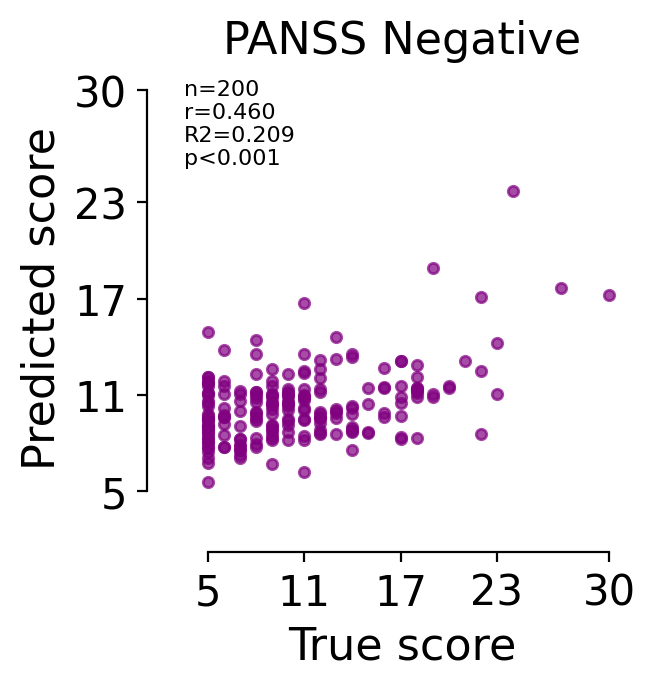

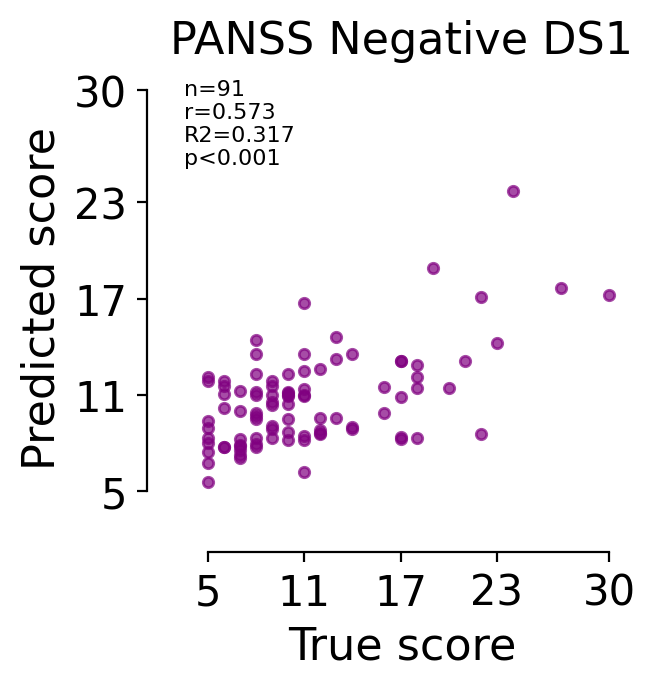

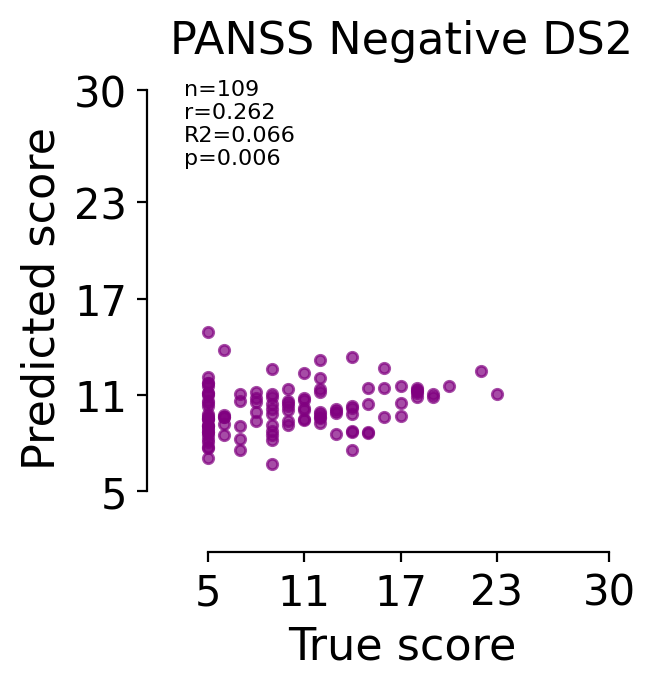


===== CPZ_equivalent_calculated / ensemble_avg_weight10p0 =====


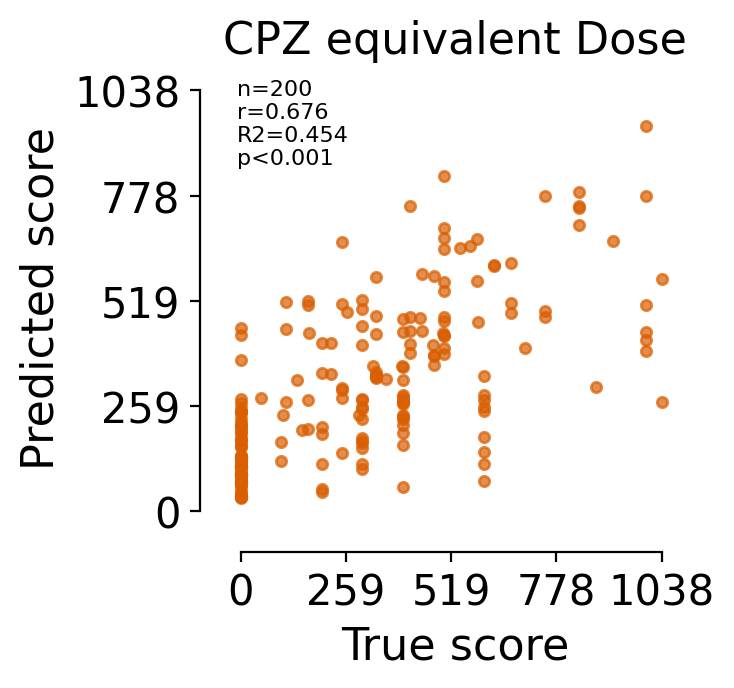

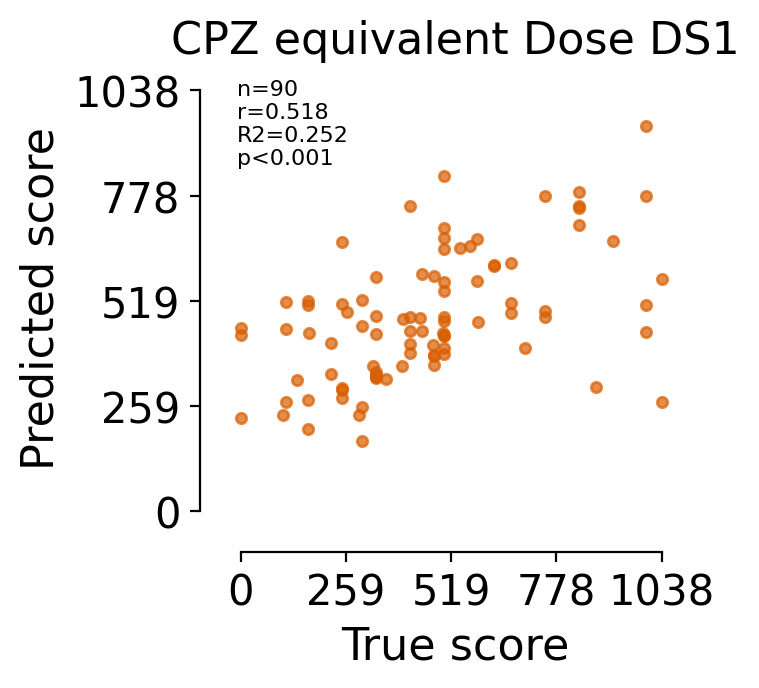

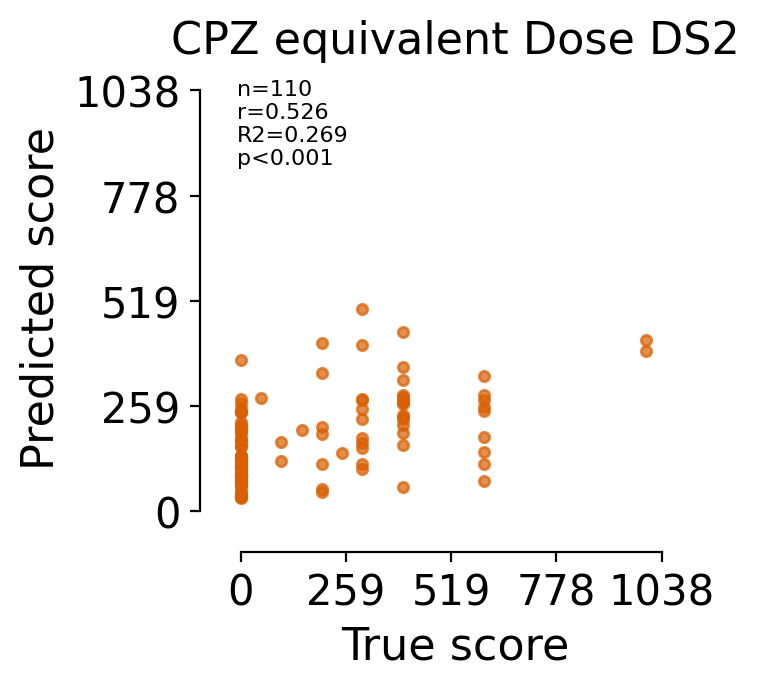


===== bacs_att / ensemble_avg_weight10p0 =====


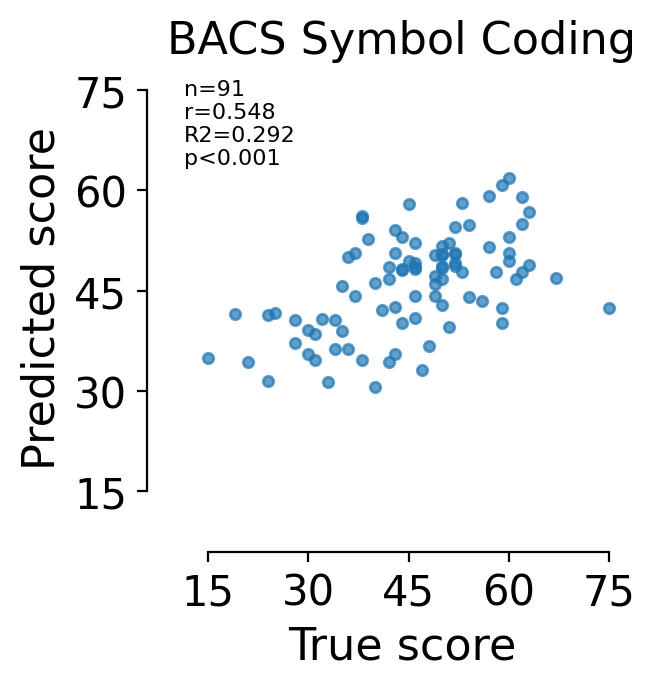

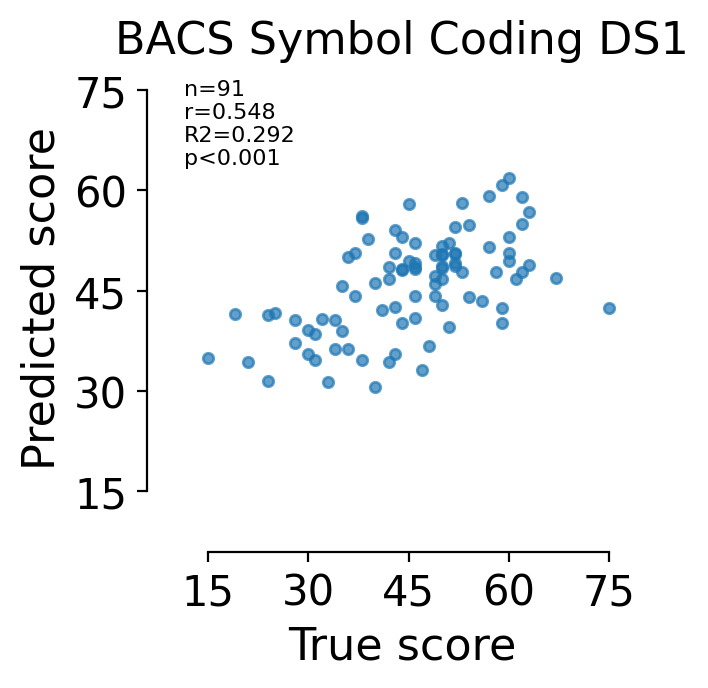


===== panss_positive / ensemble_avg_weight10p0 =====


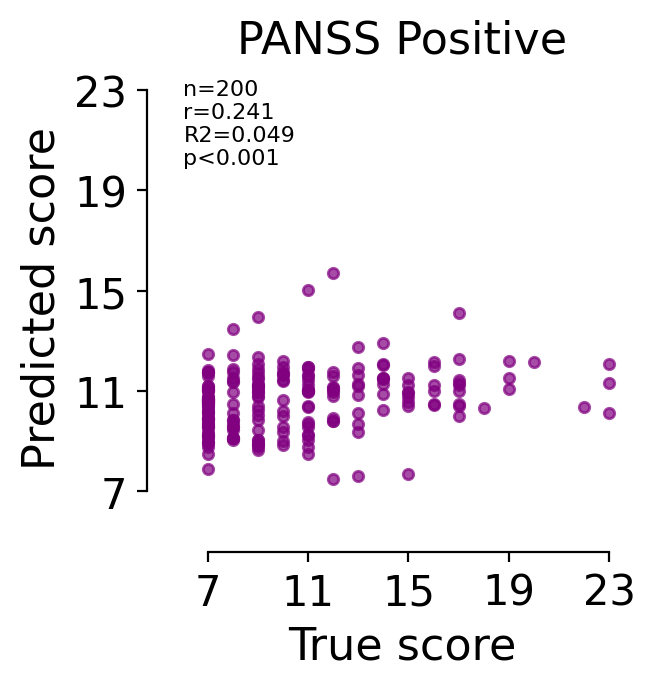

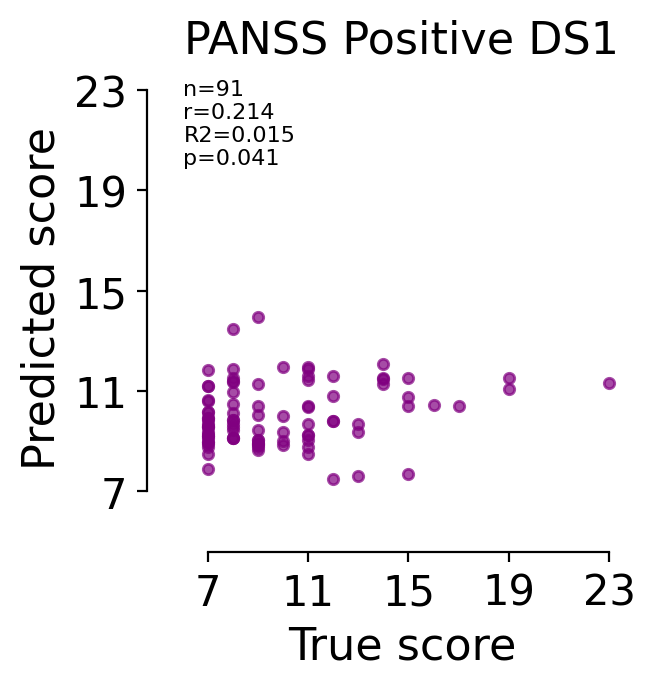

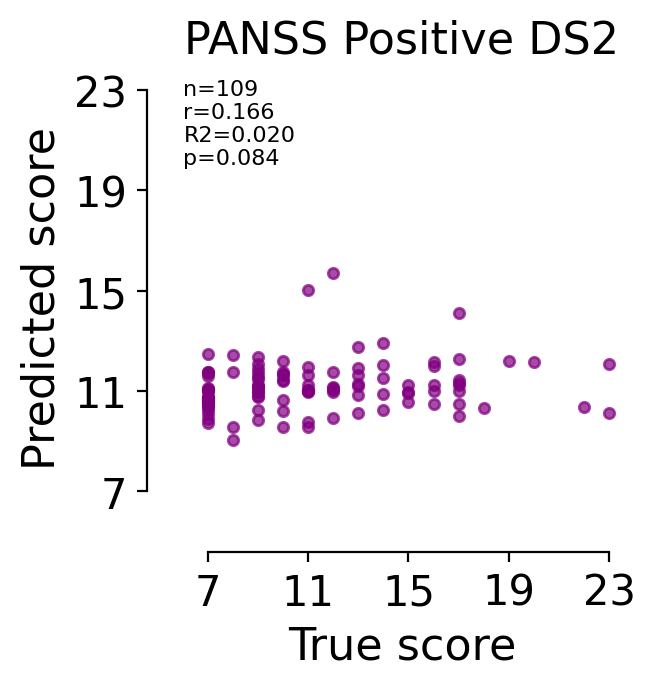


===== age_years / ensemble_avg_weight10p0 =====


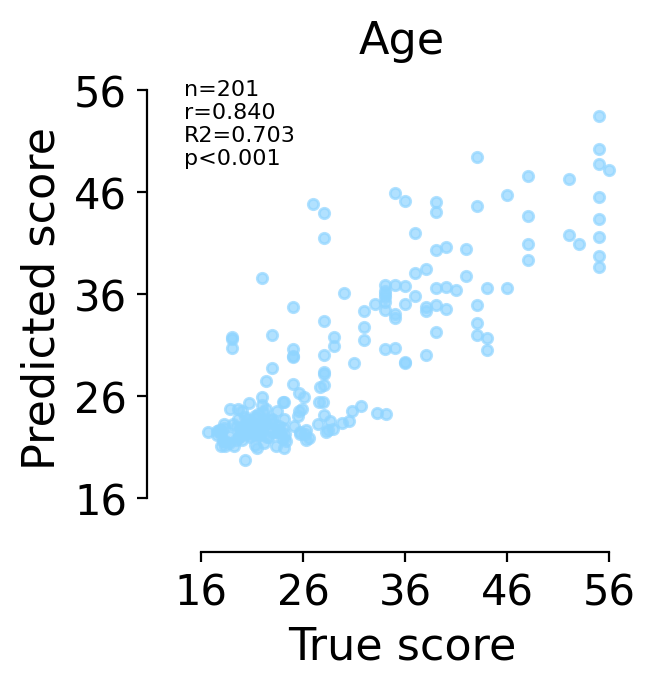

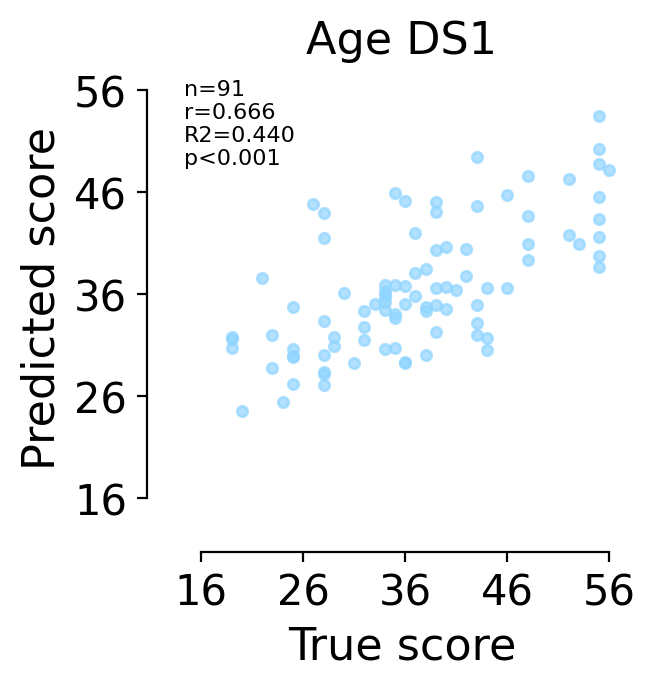

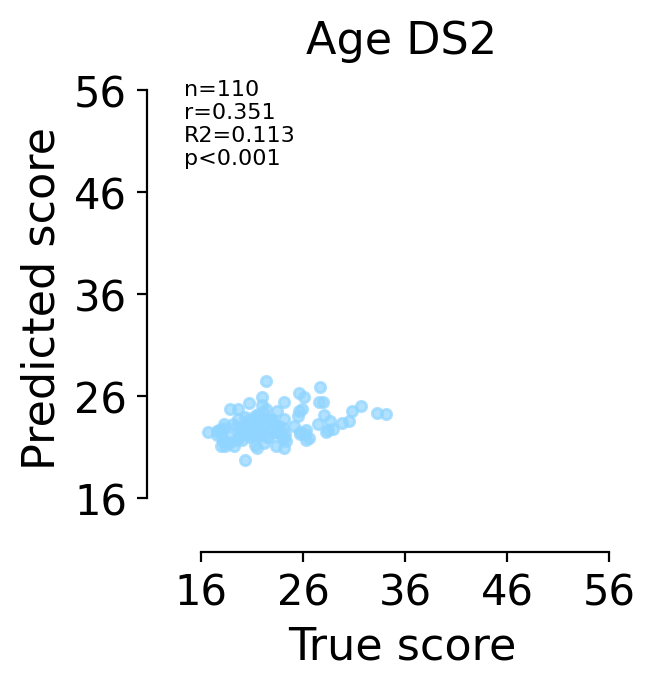


===== bnss_apathy / ensemble_avg_weight10p0 =====


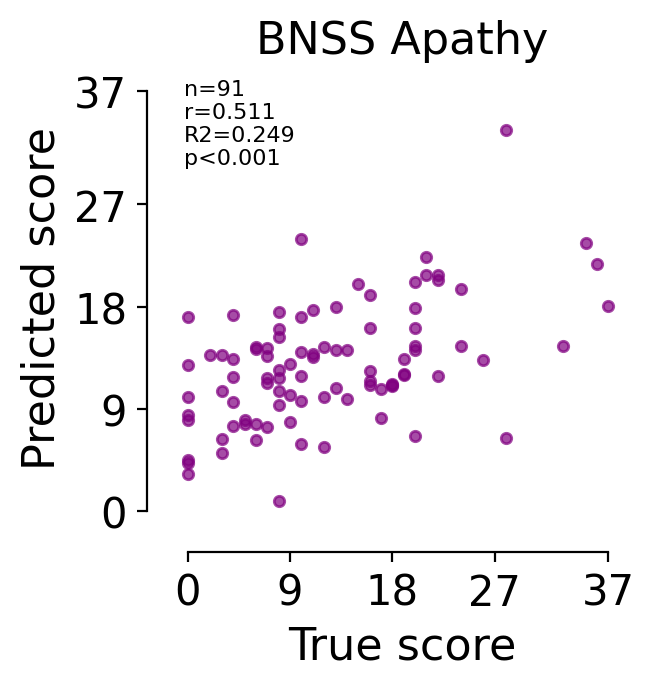

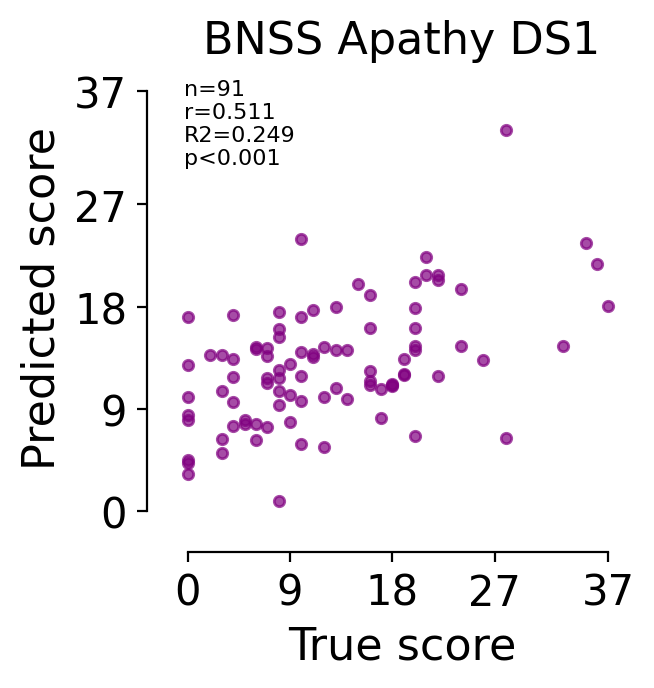


===== total_cognition_score / ensemble_avg_weight10p0 =====


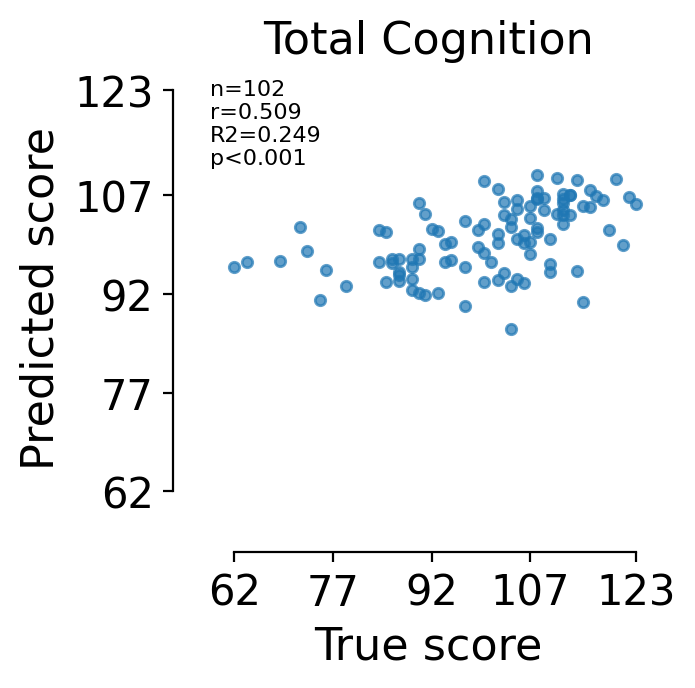

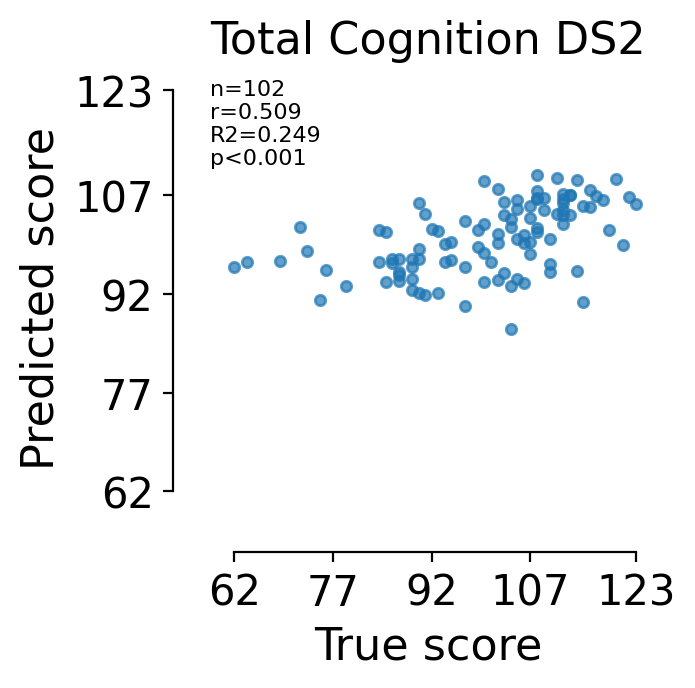

Returned: Figure(700x700)


In [16]:
out_dir = "/workspaces/CEBRA_project/Scripts_to_publish/decoder_results_only_kNN_xCEBRA"
ref_tag = "ensemble_avg_weight10p0"

plot_specs = {
    "panss_negative_EPA": {"title": "PANSS Negative", "color": "purple"},
    "panss_positive": {"title": "PANSS Positive", "color": "purple"},
    "bnss_apathy": {"title": "BNSS Apathy", "color": "purple"},
    "bacs_att": {"title": "BACS Symbol Coding", "color": "C0"},
    "age_years": {"title": "Age", "color": "#90D5FF"},
    "total_cognition_score": {"title": "Total Cognition", "color": "C0"},
    "CPZ_equivalent_calculated": {"title": "CPZ equivalent Dose", "color": "#d95f02"},
}

target_columns = ['panss_negative_EPA',
    'CPZ_equivalent_calculated',
    'bacs_att', 'panss_positive', 'age_years', 'bnss_apathy', 'total_cognition_score',
]

for tcol in target_columns:
    print(f"\n===== {tcol} / {ref_tag} =====")
    fig_te = plot_bestval_cv_and_bestval_test(
        tcol=tcol,
        ref_tag=ref_tag,
        out_dir=out_dir,
        combined_df=combined,  
        fold_root="fold_outputs",
        plot_specs=plot_specs,
        show=True,
    )

print("Returned:", fig_te)

In [ ]:
import pandas as pd
import numpy as np
import pingouin as pg
from scipy.stats import pearsonr
import os
import glob

# Ensure we have an empty list to collect our rows
table_rows = []

# Prepare the CPZ and Movement lookup dictionaries from combined_df
meta = combined[["sub_id", "session", "ds_type", "CPZ_equivalent_calculated", "mean_movement"]].copy()
meta["_sub_str"] = meta["sub_id"].astype(str).str.strip().str.replace(r'\.0$', '', regex=True)
meta["_sess_str"] = meta["session"].astype(str).str.strip().str.replace(r'\.0$', '', regex=True)

# CPZ Dictionaries
ds1_meta = meta[meta["ds_type"] == 1]
ds1_strict = {(r._sub_str, r._sess_str): r.CPZ_equivalent_calculated for _, r in ds1_meta.drop_duplicates(subset=["_sub_str", "_sess_str"]).iterrows()}
ds1_fallback = {r._sub_str: r.CPZ_equivalent_calculated for _, r in ds1_meta.drop_duplicates(subset=["_sub_str"]).iterrows()}
ds2_meta = meta[meta["ds_type"] == 2]
ds2_dict = {r._sub_str: r.CPZ_equivalent_calculated for _, r in ds2_meta.drop_duplicates(subset=["_sub_str"]).iterrows()}

# Movement Dictionaries
ds1_strict_mov = {(r._sub_str, r._sess_str): r.mean_movement for _, r in ds1_meta.drop_duplicates(subset=["_sub_str", "_sess_str"]).iterrows()}
ds1_fallback_mov = {r._sub_str: r.mean_movement for _, r in ds1_meta.drop_duplicates(subset=["_sub_str"]).iterrows()}
ds2_dict_mov = {r._sub_str: r.mean_movement for _, r in ds2_meta.drop_duplicates(subset=["_sub_str"]).iterrows()}

def get_cpz_val(row):
    sub, sess = row["_sub_str"], row["_sess_str"]
    if (sub, sess) in ds1_strict: return ds1_strict[(sub, sess)]
    if sub in ds1_fallback:       return ds1_fallback[sub]
    if sub in ds2_dict:           return ds2_dict[sub]
    return np.nan

def get_mov_val(row):
    sub, sess = row["_sub_str"], row["_sess_str"]
    if (sub, sess) in ds1_strict_mov: return ds1_strict_mov[(sub, sess)]
    if sub in ds1_fallback_mov:       return ds1_fallback_mov[sub]
    if sub in ds2_dict_mov:           return ds2_dict_mov[sub]
    return np.nan

print("Processing targets for LaTeX table...")

# Iterate through targets
for tcol in target_columns:
    fold_dir = os.path.join(out_dir, fold_root, safe_name(tcol), safe_name(ref_tag))
    te_paths = sorted(glob.glob(os.path.join(fold_dir, f"test_preds_agg_all_{safe_name(tcol)}_{safe_name(ref_tag)}_outer*.csv")))
    
    if not te_paths:
        continue
        
    df_te = pd.concat([pd.read_csv(p) for p in te_paths], ignore_index=True)
    df_te_best = df_te[df_te["is_best_val"].astype(bool)].copy()
    
    if df_te_best.empty: 
        continue
        
    # Map IDs
    sess_col = "session_grp" if "session_grp" in df_te_best.columns else ("session" if "session" in df_te_best.columns else None)
    df_te_best["_sub_str"] = df_te_best["sub_id"].astype(str).str.strip().str.replace(r'\.0$', '', regex=True)
    df_te_best["_sess_str"] = df_te_best[sess_col].astype(str).str.strip().str.replace(r'\.0$', '', regex=True) if sess_col else ""
    
    # Apply CPZ and Movement mapping
    df_te_best["CPZ_equivalent_calculated"] = df_te_best.apply(get_cpz_val, axis=1)
    df_te_best["mean_movement"] = df_te_best.apply(get_mov_val, axis=1)
    
    # Clean and run stats
    df_clean = df_te_best[["y_pred", "y_true", "CPZ_equivalent_calculated", "mean_movement"]].apply(pd.to_numeric, errors='coerce')

    row_data = {"Target": tcol}
    
    # Standard Corr
    df_std = df_clean[["y_pred", "y_true"]].dropna()
    if len(df_std) > 2:
        r_std, p_std = pearsonr(df_std["y_pred"], df_std["y_true"])
        row_data["Standard r"], row_data["Standard p"] = r_std, p_std
    else:
        row_data["Standard r"], row_data["Standard p"] = np.nan, np.nan
        
    # Partial Corr (CPZ)
    if tcol == "CPZ_equivalent_calculated":
        row_data["Partial r (CPZ)"], row_data["Partial p (CPZ)"] = np.nan, np.nan
    else:
        df_part_cpz = df_clean[["y_pred", "y_true", "CPZ_equivalent_calculated"]].dropna()
        if len(df_part_cpz) > 2:
            res_cpz = pg.partial_corr(data=df_part_cpz, x="y_pred", y="y_true", covar="CPZ_equivalent_calculated")
            p_col = next((c for c in res_cpz.columns if c in ['p-val', 'p_val', 'pval', 'p_unc']), None)
            row_data["Partial r (CPZ)"] = res_cpz['r'].values[0]
            row_data["Partial p (CPZ)"] = res_cpz[p_col].values[0] if p_col else np.nan
        else:
            row_data["Partial r (CPZ)"], row_data["Partial p (CPZ)"] = np.nan, np.nan

    # Partial Corr (Movement)
    if tcol == "mean_movement":
        row_data["Partial r (Mov)"], row_data["Partial p (Mov)"] = np.nan, np.nan
    else:
        df_part_mov = df_clean[["y_pred", "y_true", "mean_movement"]].dropna()
        if len(df_part_mov) > 2:
            res_mov = pg.partial_corr(data=df_part_mov, x="y_pred", y="y_true", covar="mean_movement")
            p_col_mov = next((c for c in res_mov.columns if c in ['p-val', 'p_val', 'pval', 'p_unc']), None)
            row_data["Partial r (Mov)"] = res_mov['r'].values[0]
            row_data["Partial p (Mov)"] = res_mov[p_col_mov].values[0] if p_col_mov else np.nan
        else:
            row_data["Partial r (Mov)"], row_data["Partial p (Mov)"] = np.nan, np.nan
            
    table_rows.append(row_data)

df_table = pd.DataFrame(table_rows)

# 3. Format the DataFrame
def fmt_r(val):
    return f"{val:.3f}" if pd.notna(val) else "-"

def fmt_p(val):
    if pd.isna(val): return "-"
    if val < 0.001: return "<0.001"
    return f"{val:.3f}"

df_formatted = pd.DataFrame()
df_formatted["Target Variable"] = df_table["Target"].str.replace("_", "\\_") 
df_formatted["Standard $r$"] = df_table["Standard r"].apply(fmt_r)
df_formatted["Standard $p$"] = df_table["Standard p"].apply(fmt_p)
df_formatted["Partial $r$ (CPZ)"] = df_table["Partial r (CPZ)"].apply(fmt_r)
df_formatted["Partial $p$ (CPZ)"] = df_table["Partial p (CPZ)"].apply(fmt_p)
df_formatted["Partial $r$ (Mov)"] = df_table["Partial r (Mov)"].apply(fmt_r)
df_formatted["Partial $p$ (Mov)"] = df_table["Partial p (Mov)"].apply(fmt_p)

# 4. Print the final LaTeX Code
print("\\begin{table}[htpb]")
print("\\centering")
print("\\caption{Model predictions vs. True scores: Standard and Confounder-Controlled Partial Correlations}")
print("\\label{tab:cpz_mov_correlations}")
# Updated column format to lcccccc (1 left-aligned, 6 centered columns)
latex_str = df_formatted.to_latex(index=False, escape=False, column_format="lcccccc")

if "\\toprule" not in latex_str:
    latex_str = latex_str.replace("\\hline", "\\toprule", 1)
    latex_str = latex_str[::-1].replace("enilh\\", "motob\\", 1)[::-1] 
    
print(latex_str)
print("\\end{table}")

Processing targets for LaTeX table...
\begin{table}[htpb]
\centering
\caption{Model predictions vs. True scores: Standard and Confounder-Controlled Partial Correlations}
\label{tab:cpz_mov_correlations}
\begin{tabular}{lcccccc}
\toprule
Target Variable & Standard $r$ & Standard $p$ & Partial $r$ (CPZ) & Partial $p$ (CPZ) & Partial $r$ (Mov) & Partial $p$ (Mov) \\
\midrule
panss\_negative\_EPA & 0.460 & <0.001 & 0.434 & <0.001 & 0.459 & <0.001 \\
CPZ\_equivalent\_calculated & 0.676 & <0.001 & - & - & 0.635 & <0.001 \\
bacs\_att & 0.548 & <0.001 & 0.558 & <0.001 & 0.543 & <0.001 \\
panss\_positive & 0.241 & <0.001 & 0.240 & <0.001 & 0.241 & <0.001 \\
age\_years & 0.840 & <0.001 & 0.807 & <0.001 & 0.761 & <0.001 \\
bnss\_apathy & 0.511 & <0.001 & 0.502 & <0.001 & 0.523 & <0.001 \\
total\_cognition\_score & 0.509 & <0.001 & 0.413 & <0.001 & 0.496 & <0.001 \\
\bottomrule
\end{tabular}

\end{table}
